In [26]:
!pip install statsbombpy mplsoccer

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from statsbombpy import sb
from mplsoccer import Pitch


pd.set_option('display.max_columns', None)

In [28]:
# Competition → Season → Match → Events

# Load available competitions
competitions = sb.competitions()
competitions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   competition_id             75 non-null     int64 
 1   season_id                  75 non-null     int64 
 2   country_name               75 non-null     object
 3   competition_name           75 non-null     object
 4   competition_gender         75 non-null     object
 5   competition_youth          75 non-null     bool  
 6   competition_international  75 non-null     bool  
 7   season_name                75 non-null     object
 8   match_updated              75 non-null     object
 9   match_updated_360          57 non-null     object
 10  match_available_360        11 non-null     object
 11  match_available            75 non-null     object
dtypes: bool(2), int64(2), object(8)
memory usage: 6.1+ KB


In [29]:
competitions.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-07-06T04:26:07.636270,2025-07-06T04:26:07.636270,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2024-09-28T01:57:35.846538,None,None,2024-09-28T01:57:35.846538
3,16,4,Europe,Champions League,male,False,False,2018/2019,2025-05-08T15:10:50.835274,2021-06-13T16:17:31.694,None,2025-05-08T15:10:50.835274
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


In [30]:
# Example: FIFA World Cup 2018
wc = competitions[(competitions['competition_name'] == 'FIFA World Cup') &
                  (competitions['season_name'] == '2018')]

competition_id = wc.iloc[0]['competition_id']
season_id = wc.iloc[0]['season_id']


competition_id, season_id

(np.int64(43), np.int64(3))

In [31]:
matches = sb.matches(competition_id=competition_id, season_id=season_id)
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   match_id               64 non-null     int64 
 1   match_date             64 non-null     object
 2   kick_off               64 non-null     object
 3   competition            64 non-null     object
 4   season                 64 non-null     object
 5   home_team              64 non-null     object
 6   away_team              64 non-null     object
 7   home_score             64 non-null     int64 
 8   away_score             64 non-null     int64 
 9   match_status           64 non-null     object
 10  match_status_360       64 non-null     object
 11  last_updated           64 non-null     object
 12  last_updated_360       64 non-null     object
 13  match_week             64 non-null     int64 
 14  competition_stage      64 non-null     object
 15  stadium                64

In [32]:
# Altrenate way: How many matches are in this competition?
matches.shape

(64, 22)

In [33]:
matches.head()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
0,7585,2018-07-03,20:00:00.000,International - FIFA World Cup,2018,Colombia,England,1,1,available,scheduled,2023-07-24T13:06:27.791230,2021-06-13T16:17:31.694,4,Round of 16,Otkritie Bank Arena,Mark Geiger,José Néstor Pekerman,Gareth Southgate,1.0.2,None,None
1,7570,2018-06-28,20:00:00.000,International - FIFA World Cup,2018,England,Belgium,0,1,available,scheduled,2023-07-24T13:06:39.637575,2021-06-13T16:17:31.694,3,Group Stage,Stadion Kaliningrad,Damir Skomina,Gareth Southgate,Roberto Martínez Montoliú,1.0.2,None,None
2,7586,2018-07-03,16:00:00.000,International - FIFA World Cup,2018,Sweden,Switzerland,1,0,available,scheduled,2023-07-24T13:05:18.578795,2021-06-13T16:17:31.694,4,Round of 16,Saint-Petersburg Stadium,Damir Skomina,Jan Olof Andersson,Vladimir Petković,1.0.2,None,None
3,7557,2018-06-25,20:00:00.000,International - FIFA World Cup,2018,Iran,Portugal,1,1,available,scheduled,2023-07-24T13:03:08.956903,2021-06-13T16:17:31.694,3,Group Stage,Mordovia Arena,Enrique Cáceres,Carlos Manuel Brito Leal Queiróz,Fernando Manuel Fernandes da Costa Santos,1.0.2,None,None
4,7542,2018-06-20,14:00:00.000,International - FIFA World Cup,2018,Portugal,Morocco,1,0,available,scheduled,2023-07-24T13:02:10.657273,2021-06-13T16:17:31.694,2,Group Stage,Stadion Luzhniki,Mark Geiger,Fernando Manuel Fernandes da Costa Santos,Hervé Renard,1.0.2,None,None


In [34]:
match_id = matches.iloc[0]['match_id']
match_id

np.int64(7585)

In [35]:
# Each row = one football action (event)
events = sb.events(match_id=match_id)
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4019 entries, 0 to 4018
Data columns (total 83 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   50_50                           4 non-null      object 
 1   bad_behaviour_card              3 non-null      object 
 2   ball_receipt_outcome            160 non-null    object 
 3   ball_recovery_recovery_failure  13 non-null     object 
 4   block_deflection                2 non-null      object 
 5   block_offensive                 1 non-null      object 
 6   carry_end_location              851 non-null    object 
 7   clearance_aerial_won            4 non-null      object 
 8   counterpress                    108 non-null    object 
 9   dribble_nutmeg                  2 non-null      object 
 10  dribble_outcome                 29 non-null     object 
 11  duel_outcome                    27 non-null     object 
 12  duel_type                       62

In [36]:
events.head()

,50_50,bad_behaviour_card,ball_receipt_outcome,ball_recovery_recovery_failure,block_deflection,block_offensive,carry_end_location,clearance_aerial_won,counterpress,dribble_nutmeg,dribble_outcome,duel_outcome,duel_type,duration,foul_committed_advantage,foul_committed_card,foul_committed_penalty,foul_committed_type,foul_won_advantage,foul_won_defensive,foul_won_penalty,goalkeeper_body_part,goalkeeper_end_location,goalkeeper_outcome,goalkeeper_position,goalkeeper_technique,goalkeeper_type,id,index,interception_outcome,location,match_id,minute,pass_aerial_won,pass_angle,pass_assisted_shot_id,pass_backheel,pass_body_part,pass_cross,pass_deflected,pass_end_location,pass_goal_assist,pass_height,pass_length,pass_outcome,pass_recipient,pass_recipient_id,pass_shot_assist,pass_switch,pass_type,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_aerial_won,shot_body_part,shot_deflected,shot_end_location,shot_first_time,shot_follows_dribble,shot_freeze_frame,shot_key_pass_id,shot_open_goal,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,substitution_outcome,substitution_outcome_id,substitution_replacement,substitution_replacement_id,tactics,team,team_id,timestamp,type,under_pressure
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,de3be98d-e227-475b-bd55-f57a6a89d308,1,NaN,NaN,7585,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Colombia,769,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 433, 'lineup': [{'player': {'id'...",Colombia,769,00:00:00.000,Starting XI,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.754,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f50ccda4-b768-4f07-9136-8f79fd17dac5,2,NaN,NaN,7585,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Colombia,769,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"{'formation': 352, 'lineup': [{'player': {'id'...",England,768,00:00:00.000,Starting XI,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.320,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,b5e98805-0a22-4a5e-a306-7d40651a0f6e,3,NaN,NaN,7585,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Colombia,769,[762b829f-5f24-4dd7-bfe2-da7e289838bb],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,England,768,00:00:00.000,Half Start,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.053,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,762b829f-5f24-4dd7-bfe2-da7e289838bb,4,NaN,NaN,7585,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,Regular Play,NaN,NaN,NaN,1,Colombia,769,[b5e98805-0a22-4a5e-a306-7d40651a0f6e],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Colombia,769,00:00:00.000,Half Start,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6b533c4f-e8c3-4e13-94ba-791f140db2b3,1652,NaN,NaN,7585,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,From Free Kick,NaN,NaN,NaN,79,England,768,[93a59d43-26aa-42cd-b899-b64db777f85e],0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Colombia,769,00:00:00.000,Half Start,NaN


In [37]:
# Location is stored as [x, y]

events['x'] = events['location'].apply(lambda loc: loc[0] if isinstance(loc, list) and len(loc) == 2 else np.nan)
events['y'] = events['location'].apply(lambda loc: loc[1] if isinstance(loc, list) and len(loc) == 2 else np.nan)

In [38]:
events[['x', 'y']].describe()

,x,y
count,3955.000000,3955.000000
mean,56.755752,39.800000
std,27.563529,23.122011
min,1.000000,1.000000
25%,35.000000,20.000000
50%,55.000000,40.000000
75%,77.000000,60.000000
max,120.000000,80.000000


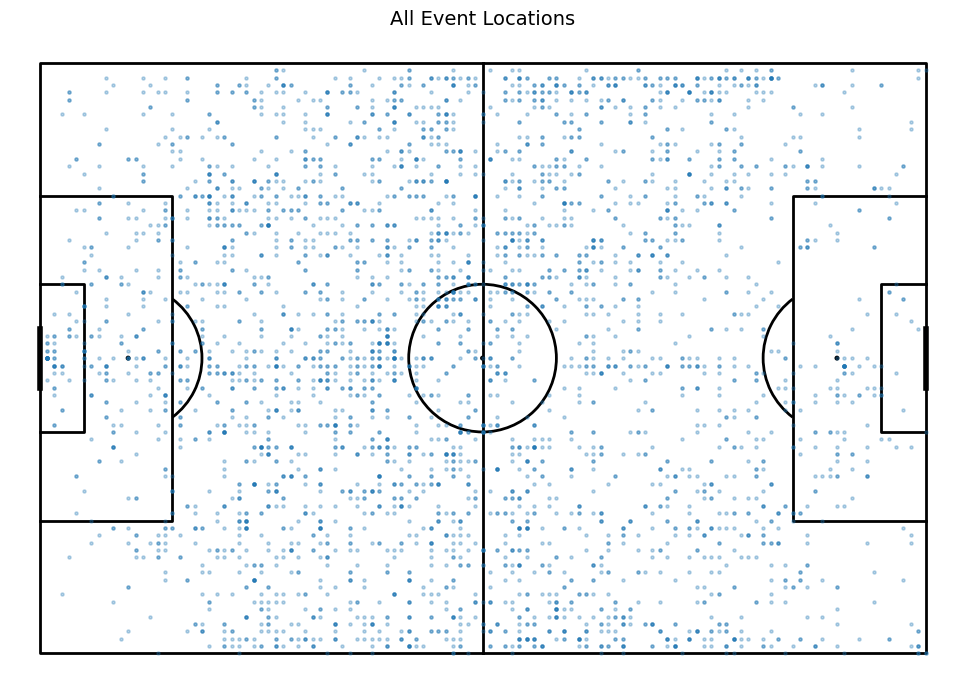

In [39]:
pitch = Pitch(pitch_type='statsbomb', line_color='black')
fig, ax = pitch.draw(figsize=(10, 7))


pitch.scatter(
    events['x'], events['y'],
    s=5,
    alpha=0.3,
    ax=ax
)


ax.set_title('All Event Locations', fontsize=14)
plt.show()

In [40]:
shots = events[events['type'] == 'Shot']

In [41]:
non_nan_columns = shots.columns[shots.notna().all()].tolist()
print("Columns with no NaN values:")
for col in non_nan_columns:
    print(col)

Columns with no NaN values:
duration
id
index
location
match_id
minute
period
play_pattern
player
player_id
position
possession
possession_team
possession_team_id
related_events
second
shot_body_part
shot_end_location
shot_outcome
shot_statsbomb_xg
shot_technique
shot_type
team
team_id
timestamp
type
x
y


In [42]:
display(shots[non_nan_columns].head())

,duration,id,index,location,match_id,minute,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,related_events,second,shot_body_part,shot_end_location,shot_outcome,shot_statsbomb_xg,shot_technique,shot_type,team,team_id,timestamp,type,x,y
3817,0.840,e2418765-e4a7-46e0-ac68-83093055e469,240,"[115.0, 18.0]",7585,5,1,From Free Kick,Ashley Young,3612.0,Left Midfield,11,England,768,[4ea18c95-ab48-4f18-b43c-ef1202f39681],22,Right Foot,"[120.0, 42.2, 2.0]",Saved,0.009816,Normal,Free Kick,England,768,00:05:22.800,Shot,115.0,18.0
3818,0.480,3d830e92-8719-4b07-aa8b-cf5772a80873,271,"[112.0, 54.0]",7585,7,1,From Free Kick,Raheem Sterling,3233.0,Right Center Forward,17,England,768,"[18a6ef03-cf85-49e6-8703-0b8fc9cb16d2, ea263d4...",6,Right Foot,"[113.0, 53.0]",Blocked,0.038204,Normal,Open Play,England,768,00:07:06.520,Shot,112.0,54.0
3819,0.280,b7213f46-90f2-4b3c-acdd-bf4f89846df9,440,"[98.0, 37.0]",7585,12,1,From Counter,Raheem Sterling,3233.0,Right Center Forward,29,England,768,"[943e4603-3dca-47ba-ad18-fec90434f682, c722f34...",40,Right Foot,"[105.0, 37.0]",Blocked,0.045128,Normal,Open Play,England,768,00:12:40.200,Shot,98.0,37.0
3820,1.013,21d8d908-8867-4d52-9a79-7eeb6360b195,549,"[119.0, 36.0]",7585,15,1,From Throw In,Harry Kane,10955.0,Left Center Forward,33,England,768,[464e55ec-f125-4fa0-8624-0d848af7c3c7],28,Head,"[120.0, 40.5, 3.1]",Off T,0.625074,Normal,Open Play,England,768,00:15:28.880,Shot,119.0,36.0
3821,0.360,e86a0564-b672-4fcf-abef-6fc15c31825c,816,"[97.0, 56.0]",7585,21,1,Regular Play,Juan Guillermo Cuadrado Bello,5689.0,Right Center Forward,42,Colombia,769,"[b064821c-e00f-43e3-9131-776c7fabde27, e01b336...",53,Right Foot,"[100.0, 54.0]",Blocked,0.021760,Normal,Open Play,Colombia,769,00:21:53.120,Shot,97.0,56.0


In [43]:
# Shot outcomes
shots['shot_outcome'].value_counts()

,count
shot_outcome,
Off T,15
Goal,9
Blocked,8
Saved,6
Wayward,2
Post,1


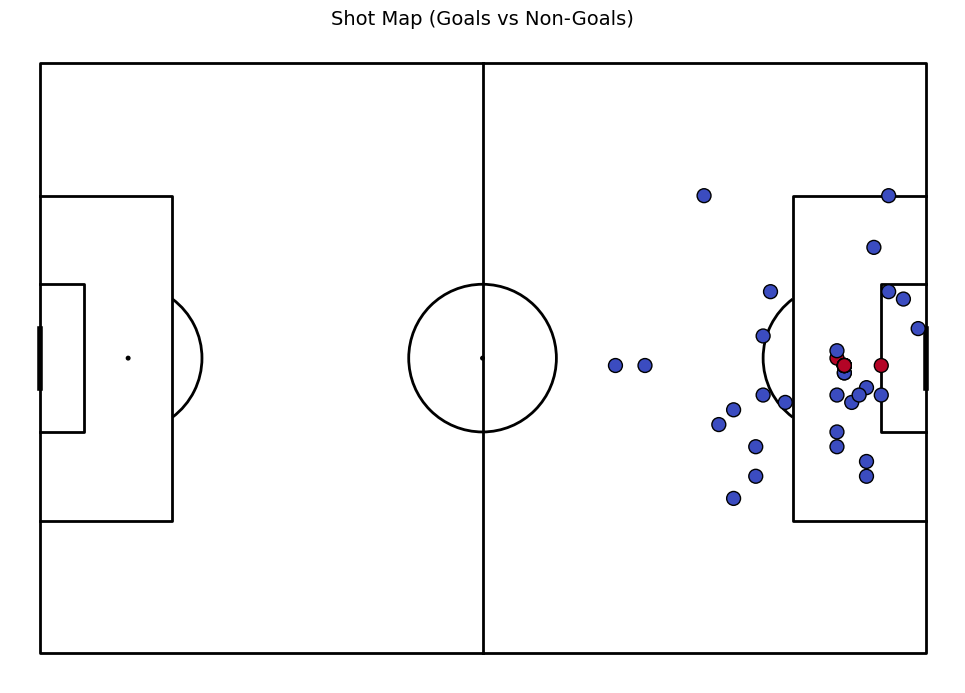

In [44]:
fig, ax = pitch.draw(figsize=(10, 7))

pitch.scatter(
    shots['x'], shots['y'],
    c=(shots['shot_outcome'] == 'Goal'),
    cmap='coolwarm',
    s=100,
    edgecolor='black',
    ax=ax
)

ax.set_title('Shot Map (Goals vs Non-Goals)', fontsize=14)
plt.show()


From the above plot, we can't differentiate the shots of the teams. We will fix that in the next cell.

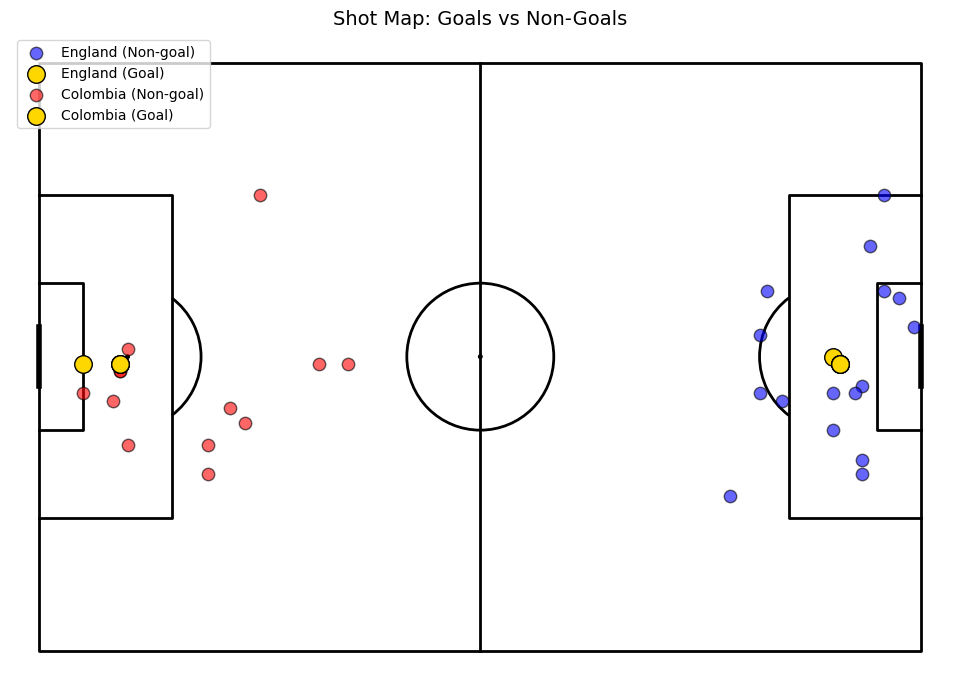

In [51]:
fig, ax = pitch.draw(figsize=(14, 7))


teams = shots['team'].unique()
home_team = teams[0]
away_team = teams[1]

# Split shots
home_shots = shots[shots['team'] == home_team].copy()
away_shots = shots[shots['team'] == away_team].copy()

# Flip away team shots
away_shots['x'] = 120 - away_shots['x']

# Non-goals (Home Team)
pitch.scatter(
    home_shots.loc[home_shots['shot_outcome'] != 'Goal', 'x'],
    home_shots.loc[home_shots['shot_outcome'] != 'Goal', 'y'],
    color='blue',
    s=80,
    alpha=0.6,
    edgecolor='black',
    ax=ax,
    label=f"{home_team} (Non-goal)"
)

# Goals (Home Team)
pitch.scatter(
    home_shots.loc[home_shots['shot_outcome'] == 'Goal', 'x'],
    home_shots.loc[home_shots['shot_outcome'] == 'Goal', 'y'],
    color='gold',
    s=160,
    edgecolor='black',
    ax=ax,
    label=f"{home_team} (Goal)",
    zorder=5
)


# Non-goals (Away Team)
pitch.scatter(
    away_shots.loc[away_shots['shot_outcome'] != 'Goal', 'x'],
    away_shots.loc[away_shots['shot_outcome'] != 'Goal', 'y'],
    color='red',
    s=80,
    alpha=0.6,
    edgecolor='black',
    ax=ax,
    label=f"{away_team} (Non-goal)"
)

# Goals (Away Team)
pitch.scatter(
    away_shots.loc[away_shots['shot_outcome'] == 'Goal', 'x'],
    away_shots.loc[away_shots['shot_outcome'] == 'Goal', 'y'],
    color='gold',
    s=160,
    edgecolor='black',
    ax=ax,
    label=f"{away_team} (Goal)",
    zorder=5
)

ax.set_title('Shot Map: Goals vs Non-Goals', fontsize=14)
ax.legend(loc='upper left')
plt.show()


In [50]:
passes = events[events['type'] == 'Pass']
non_nan_columns = passes.columns[passes.notna().all()].tolist()
display(passes[non_nan_columns].head(5))

,duration,id,index,location,match_id,minute,pass_angle,pass_end_location,pass_height,pass_length,period,play_pattern,player,player_id,position,possession,possession_team,possession_team_id,second,team,team_id,timestamp,type,x,y
12,0.24,d4883f20-ce68-4f84-b26a-a049a13cb6be,5,"[60.0, 40.0]",7585,0,3.041924,"[50.0, 41.0]",Ground Pass,10.049875,1,From Kick Off,Radamel Falcao García Zárate,3445.0,Left Center Forward,2,Colombia,769,0,Colombia,769,00:00:00.240,Pass,60.0,40.0
13,1.32,9bdb71f9-c87b-4a66-96f0-def5312ca921,9,"[51.0, 40.0]",7585,0,1.849096,"[47.0, 54.0]",Ground Pass,14.560220,1,From Kick Off,Juan Fernando Quintero Paniagua,5692.0,Center Attacking Midfield,2,Colombia,769,2,Colombia,769,00:00:02.120,Pass,51.0,40.0
14,1.16,6cb0d85d-bd14-42e3-9c2d-7f99ce437796,12,"[49.0, 55.0]",7585,0,0.982794,"[65.0, 79.0]",Ground Pass,28.844410,1,From Kick Off,Carlos Alberto Sánchez Moreno,5685.0,Right Center Midfield,2,Colombia,769,4,Colombia,769,00:00:04.200,Pass,49.0,55.0
15,1.80,f8494960-ec60-4fa4-a565-b3c89757e92b,16,"[66.0, 78.0]",7585,0,-0.564569,"[96.0, 59.0]",High Pass,35.510563,1,From Kick Off,Santiago Arias Naranjo,5696.0,Right Back,2,Colombia,769,6,Colombia,769,00:00:06.720,Pass,66.0,78.0
16,2.56,d926ec5d-b9f7-43f8-97cd-43632bcd3cb9,17,"[25.0, 22.0]",7585,0,-1.234122,"[32.0, 2.0]",High Pass,21.189621,1,From Kick Off,Harry Maguire,3336.0,Left Center Back,2,Colombia,769,8,England,768,00:00:08.520,Pass,25.0,22.0


Statsbomb offers 360 data which track not only location of an event but also players’ location. To open them we need an id of game.

In [21]:
matches = sb.matches(competition_id=43, season_id=106)
match = matches.iloc[0]

match_id = matches.iloc[0]["match_id"]

print(f"Using match_id: {match_id}")

print(f"{match['home_team']} vs {match['away_team']}")
print(f"Match date: {match['match_date']}")
# Load events and extract starting formations
events = sb.events(match_id=match_id)

starting_xi = events[events["type"] == "Starting XI"]

for _, row in starting_xi.iterrows():
    team = row["team"]
    formation = row["tactics"]["formation"]
    print(f"{team} starting formation: {formation}")


events = sb.events(match_id=match_id)
frames = sb.frames(match_id=match_id)


print("\n360 frame columns:")
print(list(frames.columns))

print("\n360 frame dataframe info:")
frames.info()


event_id = frames["id"].iloc[0]

df_frame = frames.loc[frames["id"] == event_id].copy()


coords = df_frame["location"].apply(
    lambda loc: pd.Series(loc, index=["x", "y"])
)

df_frame.loc[:, ["x", "y"]] = coords


print("\nPlayer locations at the moment of the event:")
display(df_frame[["x", "y", "teammate", "actor", "keeper"]])


print("\nVisible area of the pitch (camera coverage polygon):")
print(df_frame["visible_area"].iloc[0])


Using match_id: 3857256
Serbia vs Switzerland
Match date: 2022-12-02
Serbia starting formation: 3412
Switzerland starting formation: 4231

360 frame columns:
['id', 'visible_area', 'match_id', 'teammate', 'actor', 'keeper', 'location']

360 frame dataframe info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41562 entries, 0 to 41561
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            41562 non-null  object
 1   visible_area  41562 non-null  object
 2   match_id      41562 non-null  int64 
 3   teammate      41562 non-null  bool  
 4   actor         41562 non-null  bool  
 5   keeper        41562 non-null  bool  
 6   location      41562 non-null  object
dtypes: bool(3), int64(1), object(3)
memory usage: 1.4+ MB

Player locations at the moment of the event:


,x,y,teammate,actor,keeper
0,31.885449,47.289130,True,False,False
1,40.762566,14.657225,True,False,False
2,45.765232,69.890950,True,False,False
3,45.923999,41.324219,True,False,False
4,53.649592,31.368630,True,False,False
5,57.221077,69.484720,True,False,False
6,58.963536,49.056717,True,False,False
7,60.159949,7.849366,True,False,False
8,60.952056,27.553933,False,False,False
9,61.000000,40.099998,True,True,False



Visible area of the pitch (camera coverage polygon):
[18.8151432741548, 80.0, 44.7117185559985, 0.0, 77.1925266878704, 0.0, 104.355542805456, 80.0, 18.8151432741548, 80.0]


We want to visualize this rather than stack it in a table

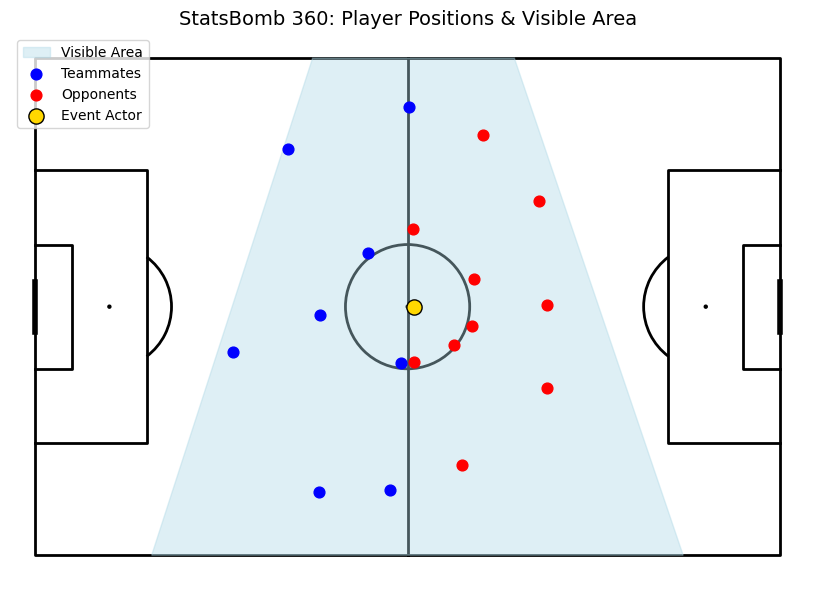

In [22]:
pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="white",
    line_color="black"
)

fig, ax = pitch.draw(figsize=(10, 6))


va = df_frame["visible_area"].iloc[0]
va_x = va[0::2]
va_y = va[1::2]

ax.fill(
    va_x, va_y,
    color="lightblue",
    alpha=0.4,
    label="Visible Area"
)

# Teammates (excluding actor)
tm = df_frame[(df_frame["teammate"]) & (~df_frame["actor"])]

# Opponents
opp = df_frame[~df_frame["teammate"]]

# Event actor
actor = df_frame[df_frame["actor"]]

pitch.scatter(
    tm["x"], tm["y"],
    color="blue", s=60, ax=ax, label="Teammates"
)

pitch.scatter(
    opp["x"], opp["y"],
    color="red", s=60, ax=ax, label="Opponents"
)

pitch.scatter(
    actor["x"], actor["y"],
    color="gold", edgecolors="black",
    s=120, ax=ax, label="Event Actor", zorder=5
)


ax.legend(loc="upper left")
ax.set_title("StatsBomb 360: Player Positions & Visible Area", fontsize=14)

plt.show()


What can you obsserve from the pitch image?